In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded=files.upload()
df=pd.read_csv("/content/food (1).csv")
df

Saving food (1).csv to food (1) (1).csv


,Age,Gender,Location,Order_History,Favorite_Cuisine,Rating,Distance_km,Delivery_Partner_Rating,Weather,Traffic_Level,Order_Time,Delivery_Time
0,36,Male,Rural,8,Italian,3.7,6.6,3.2,Rainy,Medium,Afternoon,32
1,44,Male,Urban,5,Italian,4.5,14.5,3.3,Rainy,Medium,Afternoon,68
2,34,Female,Rural,25,Italian,3.7,13.0,4.6,Rainy,Low,Morning,69
3,25,Male,Urban,22,Fast Food,4.3,11.5,3.3,Rainy,Low,Afternoon,58
4,43,Male,Rural,2,Fast Food,4.0,8.8,3.8,Cloudy,High,Evening,44
5,21,Male,Semi-Urban,20,Italian,3.2,10.1,4.5,Sunny,Medium,Night,27
6,29,Male,Urban,23,Indian,3.2,1.8,3.9,Sunny,Medium,Morning,22
7,22,Male,Urban,16,Indian,4.4,14.1,3.7,Rainy,High,Evening,26
8,31,Female,Urban,17,Fast Food,3.1,7.1,3.8,Rainy,Medium,Morning,36
9,37,Female,Rural,23,Chinese,4.2,12.9,3.2,Sunny,High,Afternoon,53


In [4]:
# Load Dataset
df = pd.read_csv("food (1).csv")

# First 10 Rows
print(df.head(10))

# Dataset Information
print(df.info())

# Shape
print(df.shape)

   Age  Gender    Location  Order_History Favorite_Cuisine  Rating  \
0   36    Male       Rural              8          Italian     3.7   
1   44    Male       Urban              5          Italian     4.5   
2   34  Female       Rural             25          Italian     3.7   
3   25    Male       Urban             22        Fast Food     4.3   
4   43    Male       Rural              2        Fast Food     4.0   
5   21    Male  Semi-Urban             20          Italian     3.2   
6   29    Male       Urban             23           Indian     3.2   
7   22    Male       Urban             16           Indian     4.4   
8   31  Female       Urban             17        Fast Food     3.1   
9   37  Female       Rural             23          Chinese     4.2   

   Distance_km  Delivery_Partner_Rating Weather Traffic_Level Order_Time  \
0          6.6                      3.2   Rainy        Medium  Afternoon   
1         14.5                      3.3   Rainy        Medium  Afternoon   
2

In [5]:
# Missing Values
print(df.isnull().sum())

# Missing Percentage
missing = (df.isnull().sum()/len(df))*100
print(missing)

# Fill Missing Values
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

# Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove Duplicates
df.drop_duplicates(inplace=True)

print(df.shape)

Age                        0
Gender                     0
Location                   0
Order_History              0
Favorite_Cuisine           0
Rating                     0
Distance_km                0
Delivery_Partner_Rating    0
Weather                    0
Traffic_Level              0
Order_Time                 0
Delivery_Time              0
dtype: int64
Age                        0.0
Gender                     0.0
Location                   0.0
Order_History              0.0
Favorite_Cuisine           0.0
Rating                     0.0
Distance_km                0.0
Delivery_Partner_Rating    0.0
Weather                    0.0
Traffic_Level              0.0
Order_Time                 0.0
Delivery_Time              0.0
dtype: float64
Duplicate Rows: 0
(50, 12)


/tmp/ipykernel_806/1224867926.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_806/1224867926.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [7]:
print(df.describe())

target = "Delivery_Time"

print("Minimum:", df[target].min())
print("Maximum:", df[target].max())
print("Mean:", df[target].mean())
print("Median:", df[target].median())

             Age  Order_History     Rating  Distance_km  \
count  50.000000      50.000000  50.000000    50.000000   
mean   32.980000      14.460000   3.842000     8.506000   
std     7.369241       8.342686   0.576085     4.021494   
min    18.000000       1.000000   3.000000     1.100000   
25%    27.000000       7.000000   3.225000     5.550000   
50%    32.500000      14.500000   3.800000     8.700000   
75%    39.000000      22.750000   4.300000    11.450000   
max    44.000000      30.000000   5.000000    15.000000   

       Delivery_Partner_Rating  Delivery_Time  
count                50.000000      50.000000  
mean                  4.000000      44.720000  
std                   0.548095      15.306448  
min                   3.100000      20.000000  
25%                   3.600000      32.000000  
50%                   3.900000      44.000000  
75%                   4.475000      57.500000  
max                   5.000000      69.000000  
Minimum: 20
Maximum: 69
Mean: 44.72


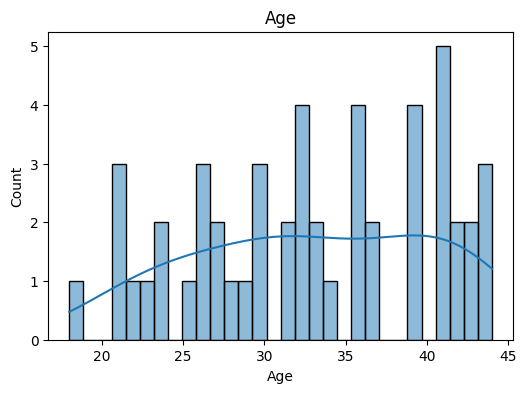

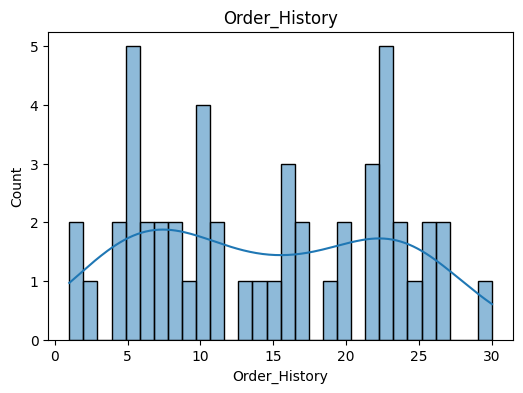

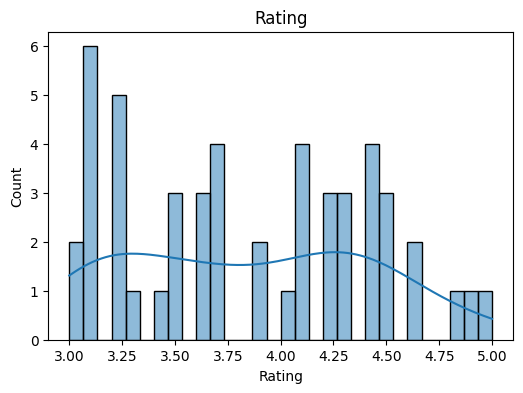

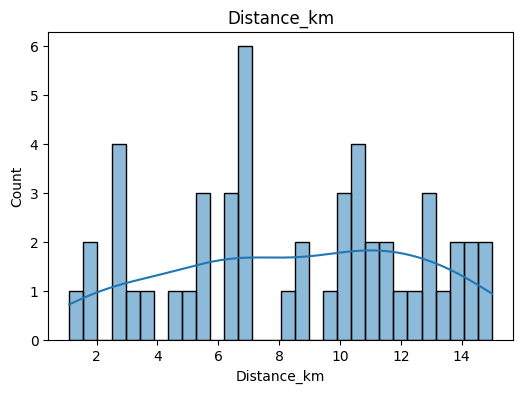

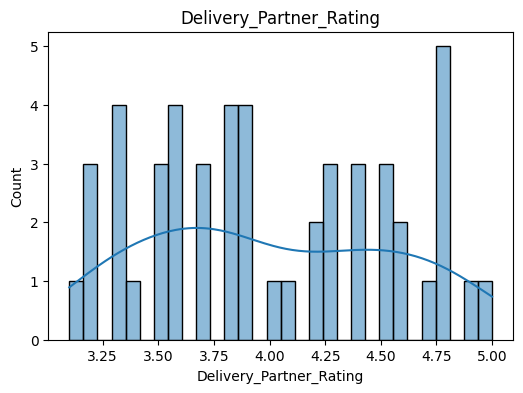

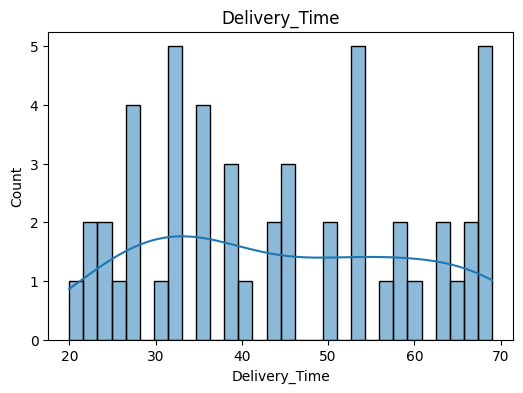

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
    plt.show()

Index(['Gender', 'Location', 'Favorite_Cuisine', 'Weather', 'Traffic_Level',
       'Order_Time'],
      dtype='object')


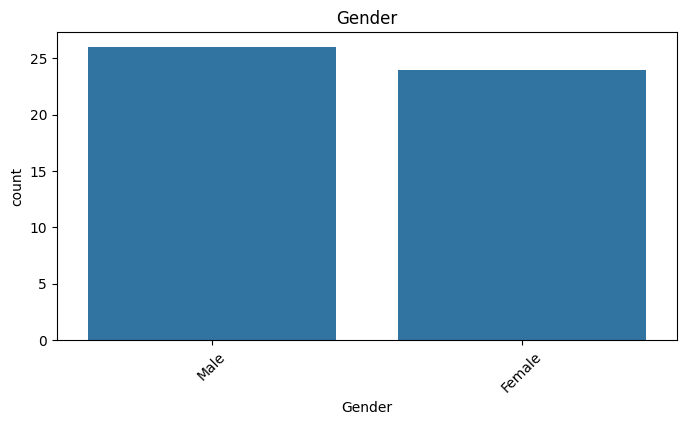

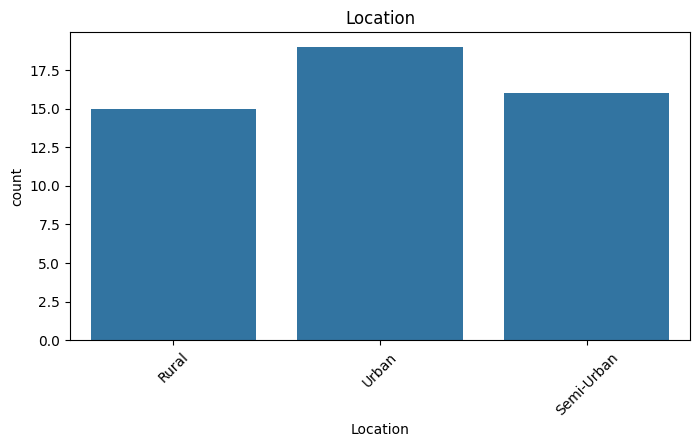

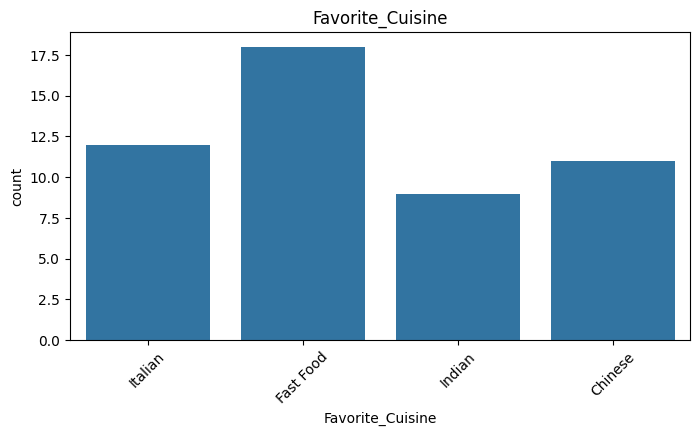

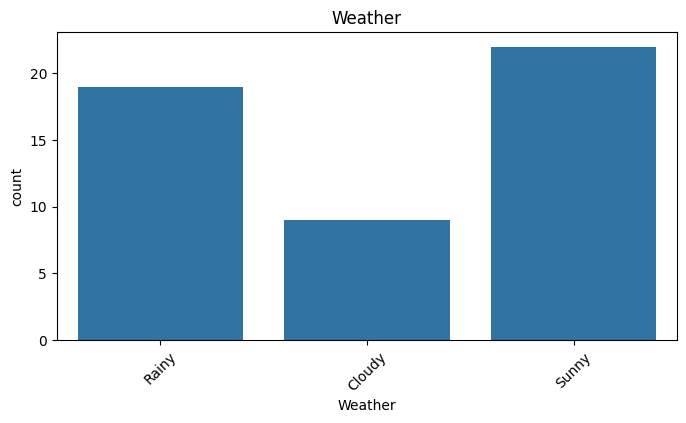

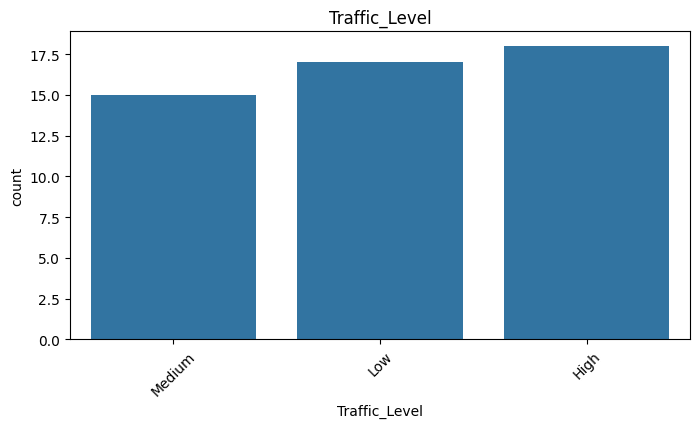

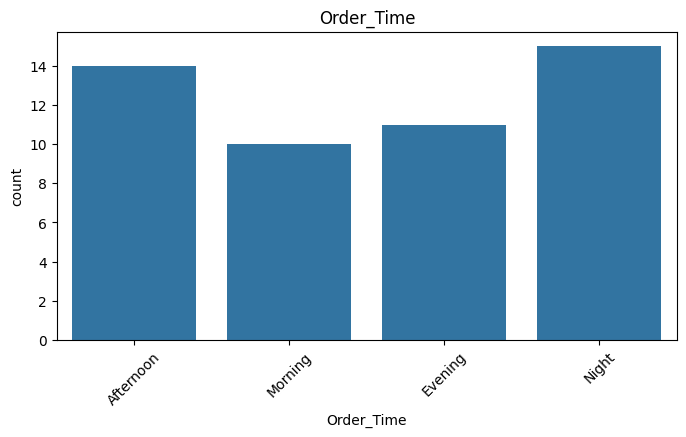

In [9]:
cat_cols = df.select_dtypes(include='object').columns

print(cat_cols)

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

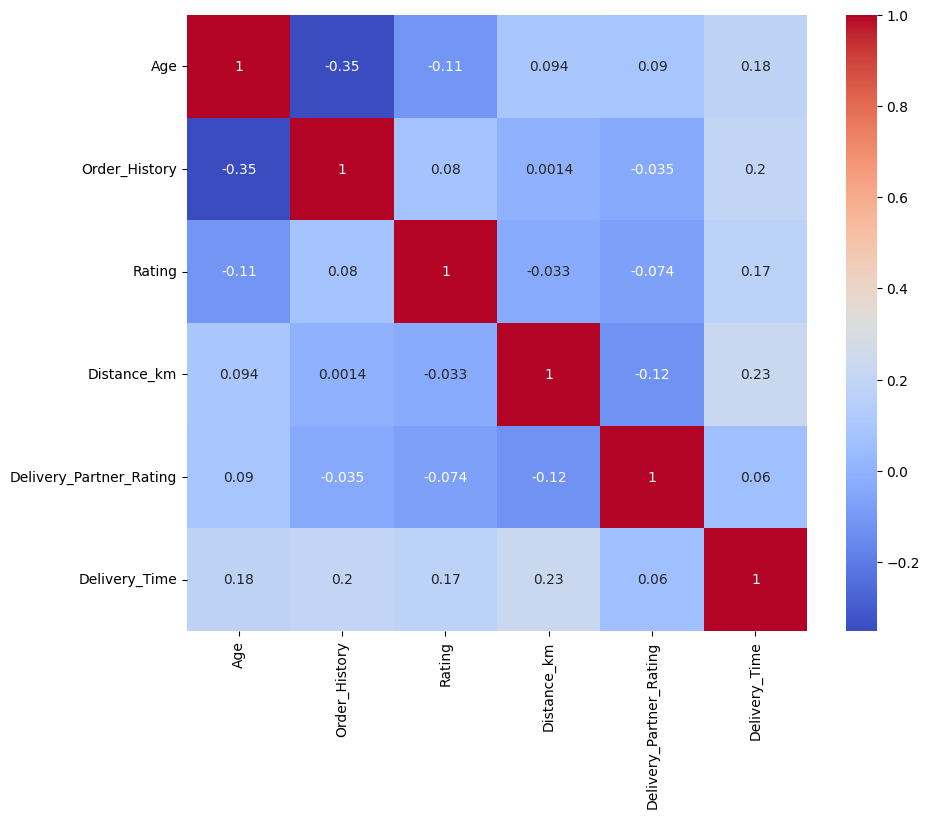

Delivery_Time              1.000000
Distance_km                0.230849
Order_History              0.201760
Age                        0.181240
Rating                     0.172397
Delivery_Partner_Rating    0.059842
Name: Delivery_Time, dtype: float64


In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

print(df.corr(numeric_only=True)["Delivery_Time"].sort_values(ascending=False))

In [13]:
X = df.drop("Delivery_Time", axis=1)

y = df["Delivery_Time"]

print("Independent Features")
print(X.columns)

print("\nDependent Feature")
print(y.name)

Independent Features
Index(['Age', 'Gender', 'Location', 'Order_History', 'Favorite_Cuisine',
       'Rating', 'Distance_km', 'Delivery_Partner_Rating', 'Weather',
       'Traffic_Level', 'Order_Time'],
      dtype='object')

Dependent Feature
Delivery_Time


In [14]:
cat_cols = X.select_dtypes(include='object').columns

print("Before Encoding")
print(X[cat_cols].head())

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("After Encoding")
print(X.head())

Before Encoding
   Gender Location Favorite_Cuisine Weather Traffic_Level Order_Time
0    Male    Rural          Italian   Rainy        Medium  Afternoon
1    Male    Urban          Italian   Rainy        Medium  Afternoon
2  Female    Rural          Italian   Rainy           Low    Morning
3    Male    Urban        Fast Food   Rainy           Low  Afternoon
4    Male    Rural        Fast Food  Cloudy          High    Evening
After Encoding
   Age  Order_History  Rating  Distance_km  Delivery_Partner_Rating  \
0   36              8     3.7          6.6                      3.2   
1   44              5     4.5         14.5                      3.3   
2   34             25     3.7         13.0                      4.6   
3   25             22     4.3         11.5                      3.3   
4   43              2     4.0          8.8                      3.8   

   Gender_Male  Location_Semi-Urban  Location_Urban  \
0         True                False           False   
1         True    

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

        Age  Order_History    Rating  Distance_km  Delivery_Partner_Rating  \
0  0.413972      -0.782192 -0.248994    -0.478765                -1.474420   
1  1.510587      -1.145440  1.153790     1.505623                -1.290117   
2  0.139818       1.276209 -0.248994     1.128841                 1.105815   
3 -1.093873       0.912961  0.803094     0.752058                -1.290117   
4  1.373510      -1.508687  0.277050     0.073849                -0.368605   

   Gender_Male  Location_Semi-Urban  Location_Urban  \
0     0.960769            -0.685994       -0.782881   
1     0.960769            -0.685994        1.277333   
2    -1.040833            -0.685994       -0.782881   
3     0.960769            -0.685994        1.277333   
4     0.960769            -0.685994       -0.782881   

   Favorite_Cuisine_Fast Food  Favorite_Cuisine_Indian  \
0                   -0.750000                -0.468521   
1                   -0.750000                -0.468521   
2                   -0.750